In [18]:
# Ucitavanje i inicijalno sredjivanje podataka
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

processedData = "../../data/processed/ProcessedData.csv"
reducedDataDir = "../../data/reduced"
outPath = os.path.join(reducedDataDir, "dataFS.csv")

df = pd.read_csv(processedData)

y = df["Class"]
X = df.drop(columns=["Class"])
X.shape

(13910, 129)

In [19]:
# Feature Selection redukcija

vt = VarianceThreshold(threshold=0.01)
varX = vt.fit_transform(X)

selectedFeatures = X.columns[vt.get_support()]
varData = pd.DataFrame(varX, columns=selectedFeatures)

corrMatrix = varData.corr().abs()
upper = corrMatrix.where(np.triu(np.ones(corrMatrix.shape), k=1).astype(bool))

corrThreshold = 0.95
drop = [col for col in upper.columns if any(upper[col] > corrThreshold)]

fsData = varData.drop(columns=drop)
fsData.shape

(13910, 29)

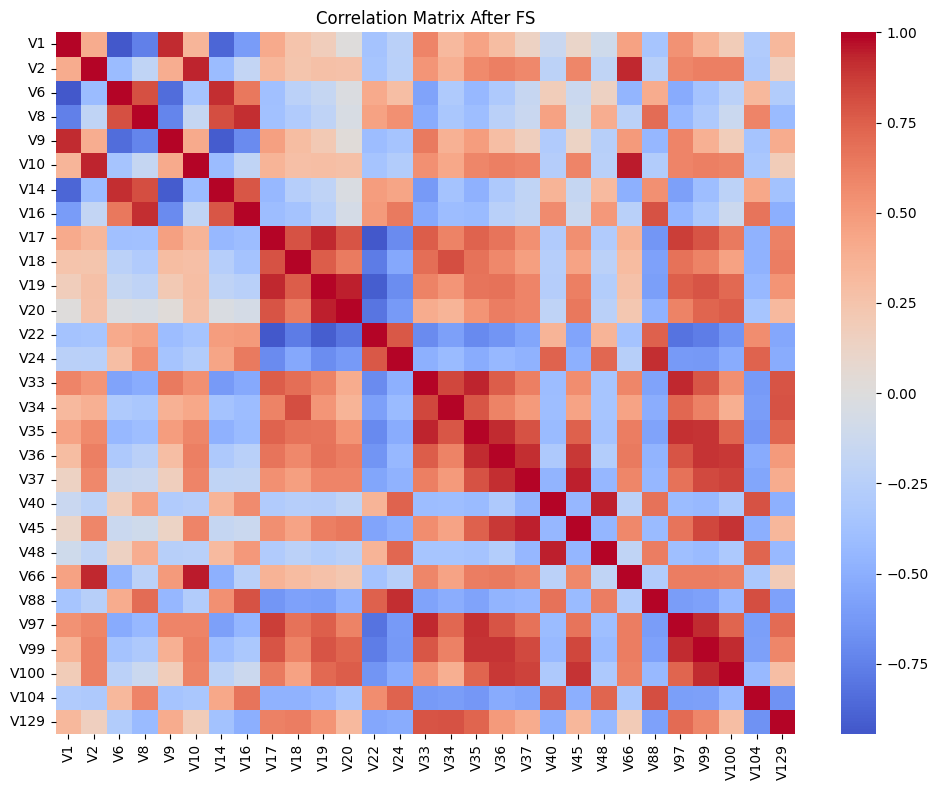

In [20]:
# Cuvanje rezultata i vizuelizacija korelacije izmedju atributa
fsData.to_csv(outPath, index=False)


plt.figure(figsize=(10, 8))
sns.heatmap(fsData.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix After FS")
plt.tight_layout()
plt.show()